# Tugas OLS, Ridge, dan Lasso Regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('Data.csv')

df.head()

,rainfall,humidity,temperature,soil_moisture,irrigation,fertilizer_A,fertilizer_B,sunlight_intensity,soil_pH,pest_index,yield
0,210,88,26,72,65,120,118,5.2,6.5,22,7.80
1,193,81,29,65,59,111,109,6.2,6.3,31,6.91
2,230,91,24,77,71,128,126,4.7,6.7,19,8.34
3,175,78,30,61,55,107,104,6.8,6.2,35,6.45
4,245,93,23,81,74,133,130,4.3,6.8,17,8.68


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rainfall            130 non-null    int64  
 1   humidity            130 non-null    int64  
 2   temperature         130 non-null    int64  
 3   soil_moisture       130 non-null    int64  
 4   irrigation          130 non-null    int64  
 5   fertilizer_A        130 non-null    int64  
 6   fertilizer_B        130 non-null    int64  
 7   sunlight_intensity  130 non-null    float64
 8   soil_pH             130 non-null    float64
 9   pest_index          130 non-null    int64  
 10  yield               130 non-null    float64
dtypes: float64(3), int64(8)
memory usage: 11.3 KB


rainfall              0
humidity              0
temperature           0
soil_moisture         0
irrigation            0
fertilizer_A          0
fertilizer_B          0
sunlight_intensity    0
soil_pH               0
pest_index            0
yield                 0
dtype: int64

### Bagian B MEMAHAMI OLS

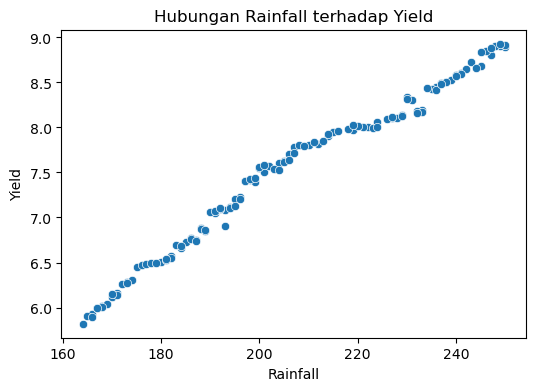

In [5]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='rainfall', y='yield', data=df)

plt.title('Hubungan Rainfall terhadap Yield')
plt.xlabel('Rainfall')
plt.ylabel('Yield')

plt.show()

In [6]:
X = df.drop('yield', axis=1)
y = df['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
ols = LinearRegression()

ols.fit(X_train_scaled, y_train)

y_pred_train_ols = ols.predict(X_train_scaled)
y_pred_test_ols = ols.predict(X_test_scaled)

In [9]:
rmse_train_ols = np.sqrt(mean_squared_error(y_train, y_pred_train_ols))
rmse_test_ols = np.sqrt(mean_squared_error(y_test, y_pred_test_ols))

r2_train_ols = r2_score(y_train, y_pred_train_ols)
r2_test_ols = r2_score(y_test, y_pred_test_ols)

print(rmse_train_ols)
print(rmse_test_ols)
print(r2_train_ols)
print(r2_test_ols)

0.031226830999439008
0.03448484155679251
0.9987944848559555
0.9979517128723636


### Bagian C MASALAH OLS

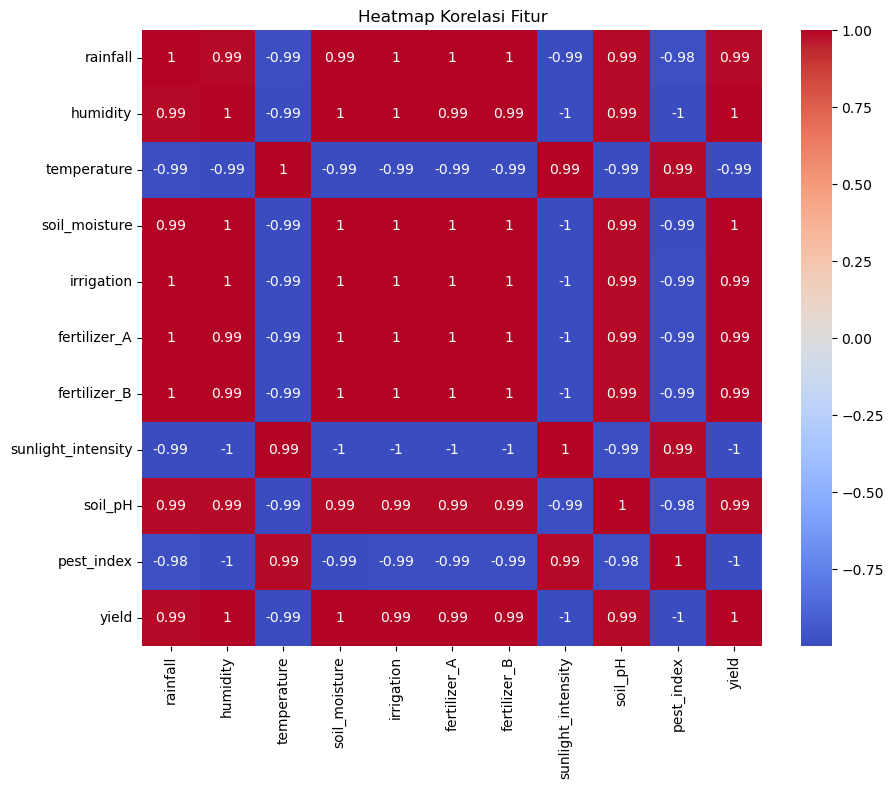

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi Fitur')
plt.show()

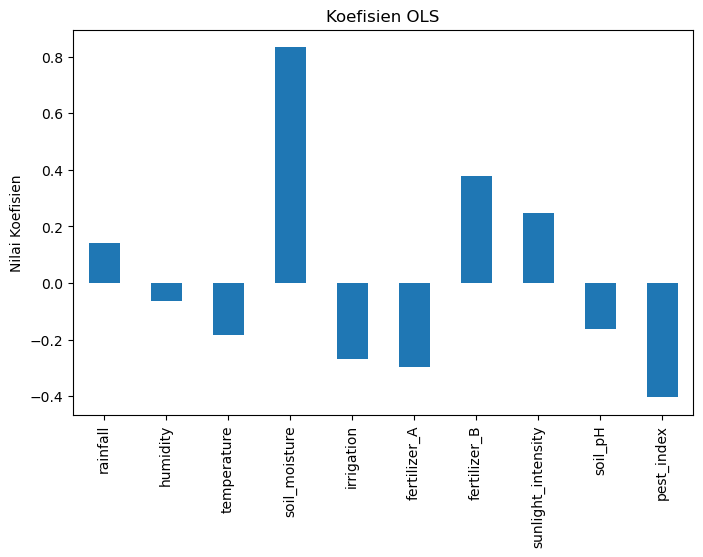

In [11]:
coef_ols = pd.Series(
    ols.coef_,
    index=X.columns
)

plt.figure(figsize=(8,5))
coef_ols.plot(kind='bar')
plt.title('Koefisien OLS')
plt.ylabel('Nilai Koefisien')
plt.show()

### Bagian D RIDGE

In [12]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

In [13]:
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

r2_train_ridge = r2_score(y_train, y_pred_train_ridge)
r2_test_ridge = r2_score(y_test, y_pred_test_ridge)

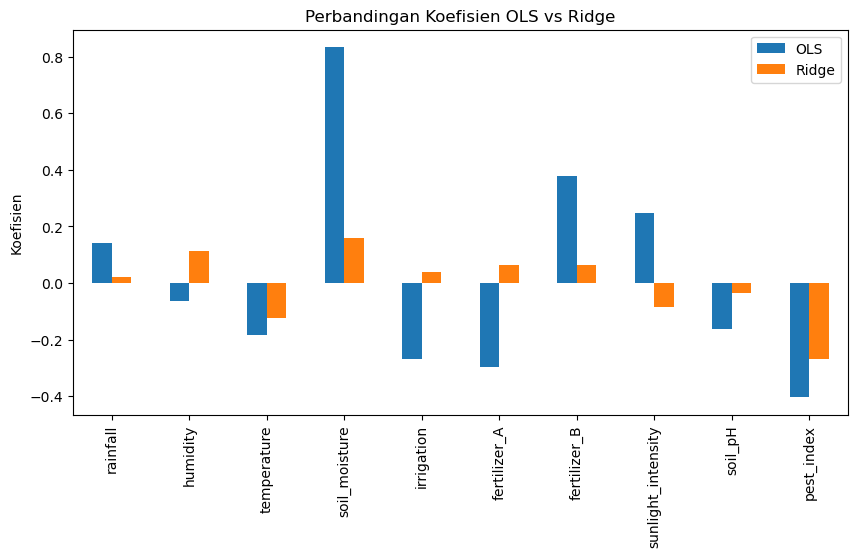

In [14]:
coef_compare = pd.DataFrame({
    'OLS': ols.coef_,
    'Ridge': ridge.coef_
}, index=X.columns)

coef_compare.plot(kind='bar', figsize=(10,5))

plt.title('Perbandingan Koefisien OLS vs Ridge')

plt.ylabel('Koefisien')

plt.show()

### Bagian E LASSO

In [15]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

In [16]:
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

r2_train_lasso = r2_score(y_train, y_pred_train_lasso)
r2_test_lasso = r2_score(y_test, y_pred_test_lasso)

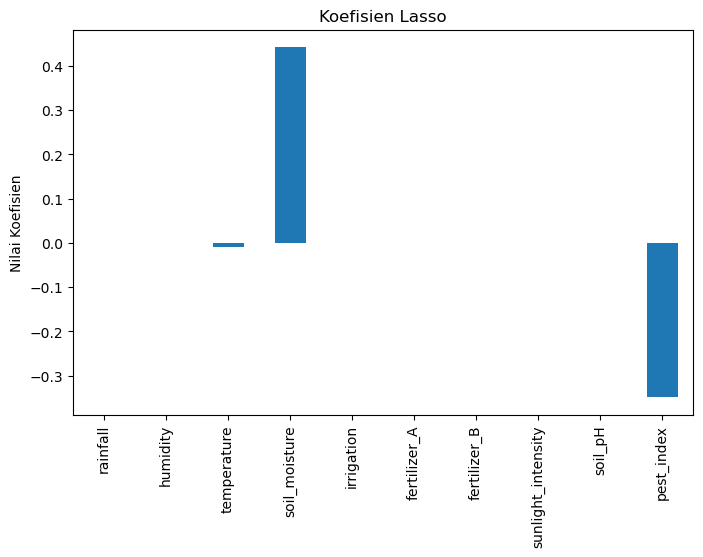

In [17]:
coef_lasso = pd.Series(
    lasso.coef_,
    index=X.columns
)

plt.figure(figsize=(8,5))

coef_lasso.plot(kind='bar')

plt.title('Koefisien Lasso')
plt.ylabel('Nilai Koefisien')
plt.show()

In [ ]:
print(coef_lasso)

rainfall              0.000000
humidity              0.000000
temperature          -0.008888
soil_moisture         0.442323
irrigation            0.000000
fertilizer_A          0.000000
fertilizer_B          0.000000
sunlight_intensity   -0.000000
soil_pH               0.000000
pest_index           -0.348676
dtype: float64


### Bagian F PERBANDINGAN

In [ ]:
results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'RMSE Train': [
        rmse_train_ols,
        rmse_train_ridge,
        rmse_train_lasso
    ],
    'RMSE Test': [
        rmse_test_ols,
        rmse_test_ridge,
        rmse_test_lasso
    ],
    'R2 Train': [
        r2_train_ols,
        r2_train_ridge,
        r2_train_lasso
    ],
    'R2 Test': [
        r2_test_ols,
        r2_test_ridge,
        r2_test_lasso
    ]
})

print(results)

   Model  RMSE Train  RMSE Test  R2 Train   R2 Test
0    OLS    0.031227   0.034485  0.998794  0.997952
1  Ridge    0.043373   0.038241  0.997674  0.997481
2  Lasso    0.107280   0.096245  0.985772  0.984045
